# 基本绘图命令介绍

最基本的绘画包：

In [1]:
# 导入 NumPy，并约定简写为 np，用于生成网格、计算数组和做线性代数。
import numpy as np
# 导入 Matplotlib 的 pyplot，并约定简写为 plt，用于二维等高线和梯度箭头图。
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)

In [3]:
x.shape

(100,)

In [6]:
X, Y = np.meshgrid(x, y)

meshgrid 的本质是坐标矩阵：

In [7]:
X

array([[0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531],
       [0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531],
       [0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531],
       ...,
       [0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531],
       [0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531],
       [0.        , 0.06346652, 0.12693304, ..., 6.15625227, 6.21971879,
        6.28318531]], shape=(100, 100))

In [8]:
X.shape

(100, 100)

In [9]:
def func(x, y):
    return np.sin(x) * np.sin(y)

因此 $Z$ 也是对应的矩阵：

In [10]:
Z = func(X, Y)

In [11]:
Z.shape

(100, 100)

In [12]:
Z

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  4.02259358e-03,  8.02898960e-03, ...,
        -8.02898960e-03, -4.02259358e-03, -1.55343800e-17],
       [ 0.00000000e+00,  8.02898960e-03,  1.60256493e-02, ...,
        -1.60256493e-02, -8.02898960e-03, -3.10062086e-17],
       ...,
       [-0.00000000e+00, -8.02898960e-03, -1.60256493e-02, ...,
         1.60256493e-02,  8.02898960e-03,  3.10062086e-17],
       [-0.00000000e+00, -4.02259358e-03, -8.02898960e-03, ...,
         8.02898960e-03,  4.02259358e-03,  1.55343800e-17],
       [-0.00000000e+00, -1.55343800e-17, -3.10062086e-17, ...,
         3.10062086e-17,  1.55343800e-17,  5.99903913e-32]],
      shape=(100, 100))

现在整个曲面的图像就被表达为 $3$ 维空间的点集： $\{(X, Y, Z)\}$，下面这段代码就是最简单的实现，遵循我们：数据 -> 对象 -> 图层 -> 样式 的逻辑：

Text(0.5, 0.92, '3D Surface')

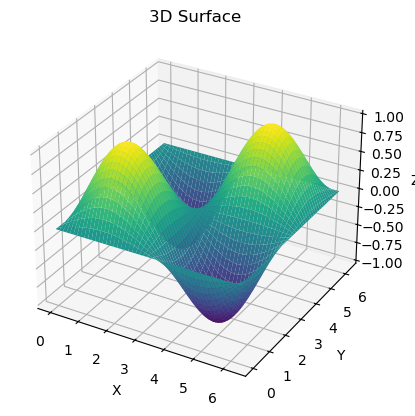

In [13]:
# 我们已经有数据 X, Y, Z
# 定义图形(figure)
fig = plt.figure()
# 定义坐标系(只有一个子图，3d投影)
ax = fig.add_subplot(111, projection='3d')
# 增加一个图层，内容是曲面，数据来自 X, Y, Z，三维需要有明暗渲染才会有立体感，所以需要一个调色板(cmap)
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

# 添加坐标轴标签和标题，即样式调整
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Surface') 

另一个常见图层是等高线(contour line):

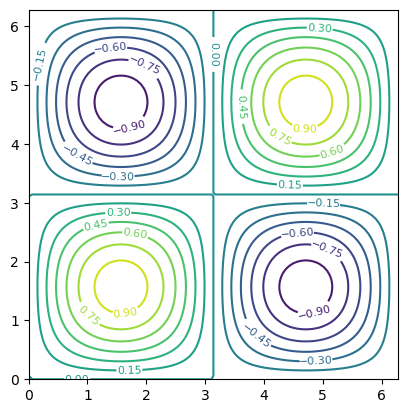

In [15]:
fig = plt.figure()
# 定义坐标系(只有一个子图，曲面的等高线是2维的)
ax = fig.add_subplot(111)
# 等高线的调色目的是看出上升和下降方向
contour = ax.contour(X, Y, Z, levels = 16, cmap='viridis')

# 不同的图层有不同样式可以调整
# 等高线可以给等高线标数值
ax.clabel(contour, inline=True, fontsize=8)
# 将长宽比调为1：1
ax.set_aspect("equal", adjustable="box")

等高线也可以用填色的方式表现，非常像曲面的俯视图：

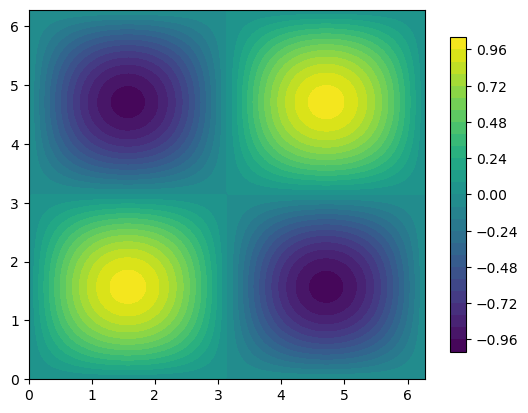

In [17]:
fig = plt.figure()
# 定义坐标系(只有一个子图，曲面的等高线是2维的)
ax = fig.add_subplot(111)
filled = ax.contourf(X, Y, Z, levels=24, cmap="viridis")
fig.colorbar(filled, ax=ax, shrink=0.85)

另一个重要的基本图层是向量场，按照数学的定义，就是空间每一点都有一个向量值，相当于要把标量场 $(X, Y, Z)$ 中的 $Z$ 变为空间维数的向量 $(QX, QY)$: 

In [18]:
# 计算func的梯度，这是一个场
def dfunc(x, y):
    return np.cos(x) * np.sin(y), np.sin(x) * np.cos(y)

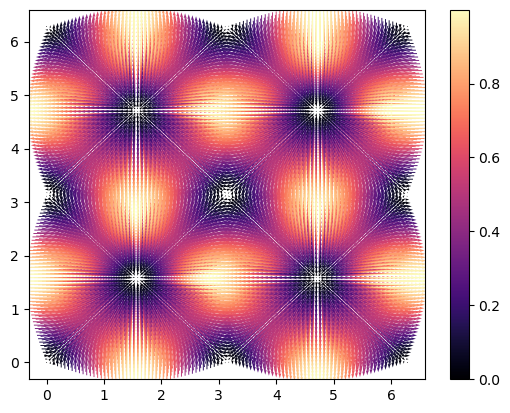

In [19]:
fig = plt.figure()
# 定义坐标系(只有一个子图，梯度场一般也是2维表现的)
ax = fig.add_subplot(111)
# 计算梯度
QX, QY = dfunc(X, Y)
# 颜色表示矢量模长
quiver = ax.quiver(X, Y, QX, QY, QX**2 + QY**2, cmap="magma", pivot="mid", scale=10)
fig.colorbar(quiver, ax=ax)

太密了，看不清。这里不光需要调整样式，也需要从数据入手调整：

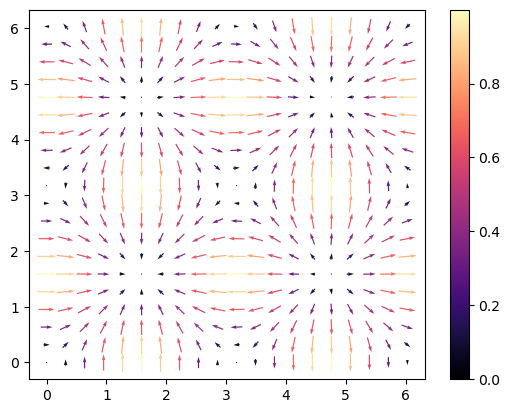

In [20]:
# 降低采样密度, 每 5 个点采样一次
XQ =  X[::5,::5]
YQ =  Y[::5,::5]
# 重新计算稀疏梯度场
QX, QY = dfunc(XQ, YQ)
fig = plt.figure()
ax = fig.add_subplot(111)
quiver = ax.quiver(XQ, YQ, QX, QY, QX**2 + QY**2, cmap="magma", pivot="mid", scale=20)
fig.colorbar(quiver, ax=ax)

这样得到的是静态图片。可以用于论文等纸质出版物。下面介绍进阶多图层动态展示，可以用于报告。首先我们需要调用 plotly 库：

In [21]:
# 导入 Plotly 的底层图形对象接口，并约定简写为 go，用于三维曲面和交互图。
import plotly.graph_objects as go
# 导入 Plotly 子图工具，用于把三维曲面和二维等高线并排显示。
from plotly.subplots import make_subplots

我们数据已经有了，先来看看什么叫交互性：

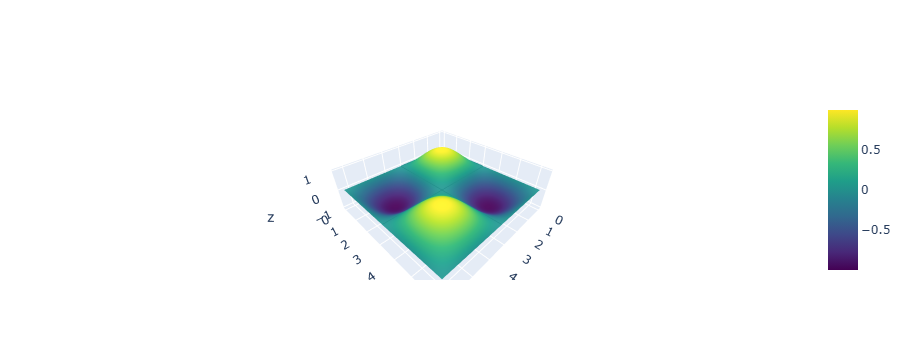

In [23]:
fig = go.Figure()
surface = go.Surface(
    x=X,
    y=Y,
    z=Z,
    colorscale="Viridis",
    contours={"z": {"show": True, "usecolormap": True}},
)
fig.add_trace(surface)

plotly 允许多图层叠加：

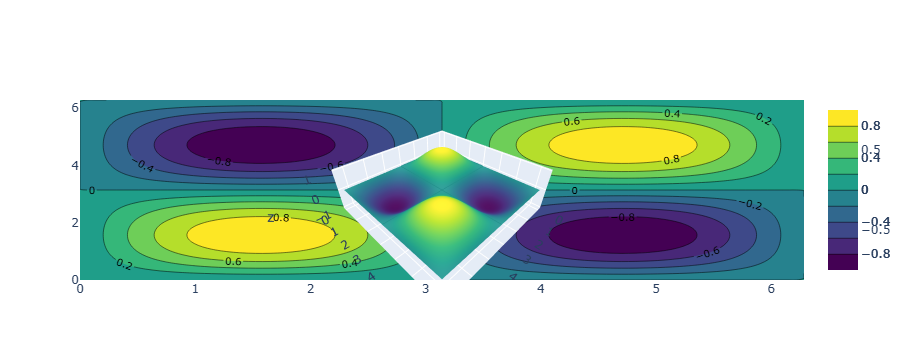

In [25]:
contour = go.Contour(
    x=x,
    y=y,
    z=Z,
    colorscale="Viridis",
    contours={"showlabels": True,
    "labelfont": {"size": 10}},
)
fig.add_trace(contour)

但这样显然不够优雅。可以用子图规划一下：

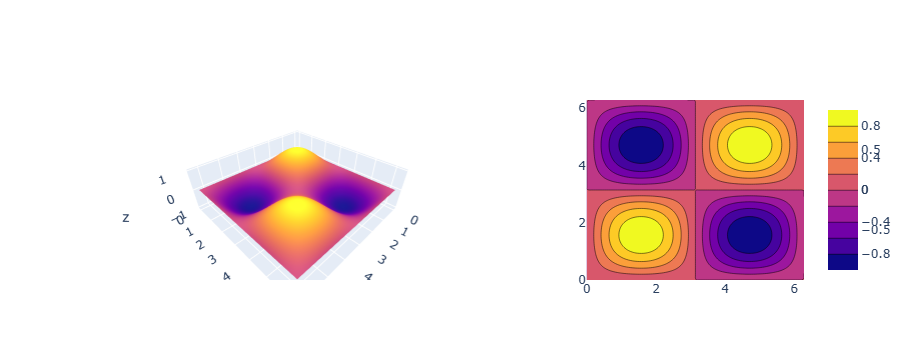

In [26]:
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.66, 0.33],  # 关键修改：第一列占2/3，第二列占1/3
    specs=[[{"type": "surface"}, {"type": "contour"}]],
)
fig.add_trace(go.Surface(x=X, y=Y, z=Z), row=1, col=1)
fig.add_trace(go.Contour(x=x, y=y, z=Z), row=1, col=2)

如果输入的参数比较复杂，那么 ipywidgets 提供了更加丰富的输入和交互方式：

In [27]:
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, IntSlider, FloatSlider

# 创建一个整数滑块，范围 0-10，初始值 5，步长 1
int_slider = widgets.IntSlider(value=5, min=0, max=10, step=1, description='整数：')
# 创建一个浮点数滑块，范围 0.0-1.0，初始值 0.5，步长 0.01
float_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='浮点数：')

# 显示滑块
display(int_slider, float_slider)

IntSlider(value=5, description='整数：', max=10)

FloatSlider(value=0.5, description='浮点数：', max=1.0, step=0.01)

整个花活：

In [28]:
def plot_surface_plotly(f=50):
      x = np.linspace(0, 2*np.pi, 100)
      y = np.linspace(0, 2*np.pi, 100)
      X, Y = np.meshgrid(x, y)
      Z = np.sin(f*X) * np.sin(Y)

      fig = go.Figure(data=[
          go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')
      ])

      fig.update_layout(
          title=f'z = sin(f * x) · sin(y)',
          scene=dict(
              xaxis_title='x',
              yaxis_title='y',
              zaxis_title='z'
          ),
          width=700,
          height=600
      )

      fig.show()

slider = FloatSlider(min=0, max=10, step=0.1, value=1.0, description='X 方向震荡')
interact(plot_surface_plotly, f=slider);

interactive(children=(FloatSlider(value=1.0, description='X 方向震荡', max=10.0), Output()), _dom_classes=('widget…

为了讨论隐函数，需要引入解析计算包：

In [30]:
import sympy as sp

# 定义三个符号变量，写作 x_sym, y_sym, z_sym；显示为 x, y, z
x_sym, y_sym, z_sym = sp.symbols("x y z")
# 定义三个符号变量，写作 t_sym, u_sym, v_sym；显示为 t, u, v
t_sym, u_sym, v_sym = sp.symbols("t u v")
 
# 定义表达式 expr := t
expr = sp.sin(t_sym)
# 求 expr 关于 t 的导数
dexpr_dt = sp.diff(expr, t_sym)

解析计算具有精确的形式：

In [34]:
expr + 1

sin(t) + 1

In [32]:
dexpr_dt

cos(t)

代入运算也只有精确的形式：

In [35]:
expr_at_2 = expr.subs(t_sym, 2)
expr_at_2

sin(2)

In [36]:
np.sin(2)

np.float64(0.9092974268256817)

如果要进行数值计算，必须自动转成数值计算函数：

In [37]:
# 将 expr 转成数值计算函数 f
f = sp.lambdify(t_sym, expr, modules="numpy")
# 将 expr 的导函数 dexpr_dt 转成数值计算函数 df_dt
df_dt = sp.lambdify(t_sym, dexpr_dt, modules="numpy")

In [38]:
f(2.0)

np.float64(0.9092974268256817)

In [39]:
df_dt(2.0)

np.float64(-0.4161468365471424)

下面是用解析参数方程绘制单位圆的例子：

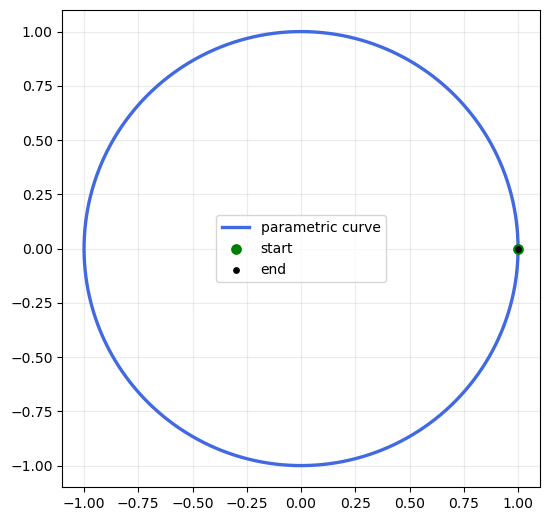

In [40]:
x_expr = sp.cos(t_sym)
y_expr = sp.sin(t_sym)

x_func = sp.lambdify(t_sym, x_expr, modules="numpy")
y_func = sp.lambdify(t_sym, y_expr, modules="numpy")

t = np.linspace(0, 2 * np.pi, 600)
x_circle = x_func(t)
y_circle = y_func(t)



fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot(x_circle, y_circle, color="royalblue", linewidth=2.4, label="parametric curve")
ax.scatter([x_circle[0]], [y_circle[0]], color="green", s=45, label="start", zorder=4)
ax.scatter([x_circle[-1]], [y_circle[-1]], color="black", s=15, label="end", zorder=4)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()

用解析表达式的好处是可以解析求导，注意这个只能用于展示和数学推导，不能用于计算！

In [ ]:
dx_dt_func = sp.lambdify(t_sym, sp.diff(x_expr, t_sym), modules="numpy")
dy_dt_func = sp.lambdify(t_sym, sp.diff(y_expr, t_sym), modules="numpy")

三维参数曲面比较方便的是直接用plotly绘制：

In [ ]:
# 二维参数空间 (u, v) 网格
u = np.linspace(0.05, np.pi - 0.05, 90)
v = np.linspace(0, 2 * np.pi, 120)
U, V = np.meshgrid(u, v, indexing="ij")

# 映射到三维欧氏空间的曲面
X_sphere = np.sin(U) * np.cos(V)
Y_sphere = np.sin(U) * np.sin(V)
Z_sphere = np.cos(U)

然后三维空间直出即可：

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=X_sphere,
        y=Y_sphere,
        z=Z_sphere,
        opacity=1,
        colorbar={"title": "参数"},
        name="参数曲面",
    )
)
fig.update_scenes(xaxis_title="x", yaxis_title="y",
                  zaxis_title="z", aspectmode="data")
fig.show()

三维的隐函数绘制：

In [ ]:
def Func(x, y, z):
    return x**2 + y**2 + z**2 

n = 60
# 三维曲面计算，其实是四维空间 （x, y, z, f(x, y, z)） 采样
x = np.linspace(-2, 2, n)
y = np.linspace(-2, 2, n)
z = np.linspace(-2, 2, n)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
values = np.asarray(Func(X, Y, Z), dtype=float)

In [ ]:
from skimage.measure import marching_cubes

dx = 4 / (n - 1)
dy = 4 / (n - 1)
dz = 4 / (n - 1)

vertices, faces, _, _ = marching_cubes(
    values,
    level=1,  # 单位球面，值为 1 的等值面
    spacing=(dx, dy, dz),
)
vertices += np.array([-2, -2, -2])

marching_cubes 的核心输出就是一个三角形网格，用来近似某个三维隐式等值面，比如：

  vertices, faces, normals, values = marching_cubes(values, level=1)

  其中：

  - vertices：三角网格的顶点坐标，形状通常是 (n_vertices, 3)。
  - faces：三角形面片的顶点索引，形状通常是 (n_faces, 3)。
  - normals：每个顶点的法向量，可用于光照/渲染。
  - values：每个顶点附近的标量值信息。

  比如 faces[i] = [12, 45, 78] 表示第 i 个三角形由：

  vertices[12], vertices[45], vertices[78]

  这三个顶点组成。

  所以在 BasicPlot.ipynb 里，marching_cubes 是把隐函数
$$
  x^2 + y^2 + z^2 = 1
$$
  近似提取成很多小三角形，然后将这个三角形面画出来：

In [ ]:
fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],  # 三角形顶点
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], # i,j,k 次序
            color="steelblue",
            opacity=0.6,
            flatshading=True,  # 给点阴影
            lighting={"ambient": 0.55, "diffuse": 0.75, "specular": 0.25},  # 给点光照
            name="隐式曲面",
        )
    ]
)
fig.show()

In [ ]:
  edges = set()
  for tri in faces:
      a, b, c = map(int, tri)
      edges.add(tuple(sorted((a, b))))
      edges.add(tuple(sorted((b, c))))
      edges.add(tuple(sorted((c, a))))

  x_edges, y_edges, z_edges = [], [], []

  for a, b in edges:
      p0 = vertices[a]
      p1 = vertices[b]

      x_edges += [p0[0], p1[0], None]
      y_edges += [p0[1], p1[1], None]
      z_edges += [p0[2], p1[2], None]

  fig = go.Figure(
      data=[
          go.Scatter3d(
              x=x_edges,
              y=y_edges,
              z=z_edges,
              mode="lines",
              line=dict(color="black", width=2),
          )
      ]
  )

  fig.update_layout(scene_aspectmode="data")
  fig.show()